In [40]:
# Importing required libraries
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [41]:
# Downloading required NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [43]:
# Step 1: Loading and cleaning the dataset
file_path = 'twitter_training.csv'
data = pd.read_csv(file_path)

In [44]:
# Rename columns for clarity
data.columns = ['ID', 'Topic', 'Sentiment', 'Text']

In [45]:
# Drop irrelevant columns and handle missing values
data = data[['Sentiment', 'Text']].dropna()

In [49]:
# Step 2: Preprocessing the text
def preprocess_text(text):
    # Removing special characters and lowercase text
    text = re.sub(r'[^a-zA-Z\s]', '', text).lower()

    # Tokenizing and removing stopwords
    stop_words = set(stopwords.words('english'))
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatizing tokens
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(tokens)

# Apply preprocessing
data['Cleaned_Text'] = data['Text'].apply(preprocess_text)


In [50]:
# Step 3: Performing sentiment analysis
# Split the data into training and testing sets
X = data['Cleaned_Text']
y = data['Sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [51]:
# Converting text to numerical data using CountVectorizer
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [52]:
# Train a Naive Bayes classifier
model = MultinomialNB()
model.fit(X_train_vec, y_train)

MultinomialNB()

In [53]:
# Predicting on the test set
y_pred = model.predict(X_test_vec)

In [54]:

# Evaluating the model
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

  Irrelevant       0.83      0.60      0.70      2624
    Negative       0.69      0.84      0.76      4463
     Neutral       0.81      0.63      0.71      3589
    Positive       0.70      0.80      0.75      4123

    accuracy                           0.74     14799
   macro avg       0.76      0.72      0.73     14799
weighted avg       0.75      0.74      0.73     14799

Confusion Matrix:
 [[1569  484  122  449]
 [  90 3747  207  419]
 [ 124  674 2253  538]
 [ 105  496  204 3318]]
Accuracy: 0.7356578147172106


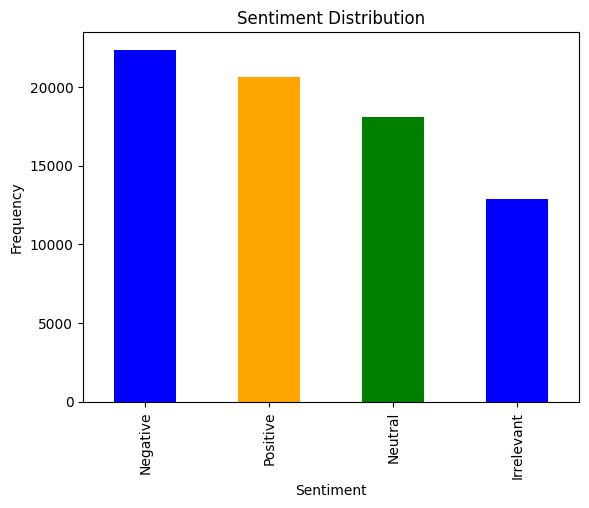

In [55]:

# Step 4: Visualizing sentiment patterns
# Counting the occurrences of each sentiment
data['Sentiment'].value_counts().plot(kind='bar', color=['blue', 'orange', 'green'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Frequency')
plt.show()


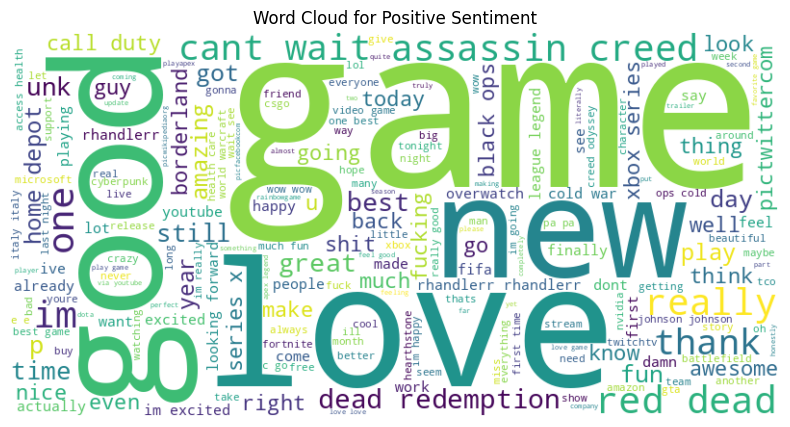

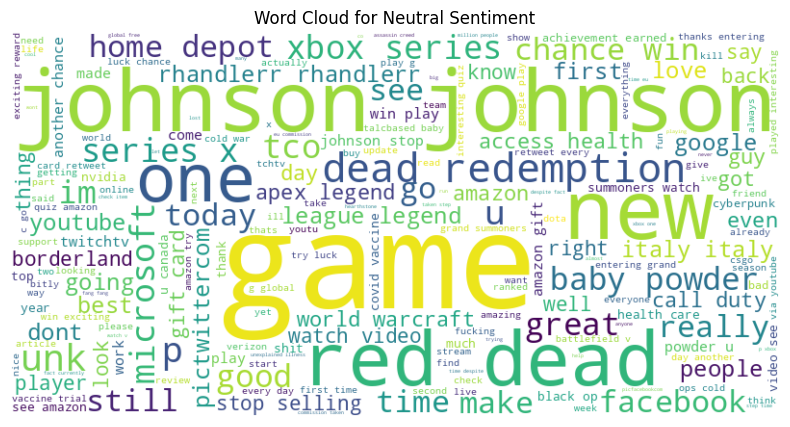

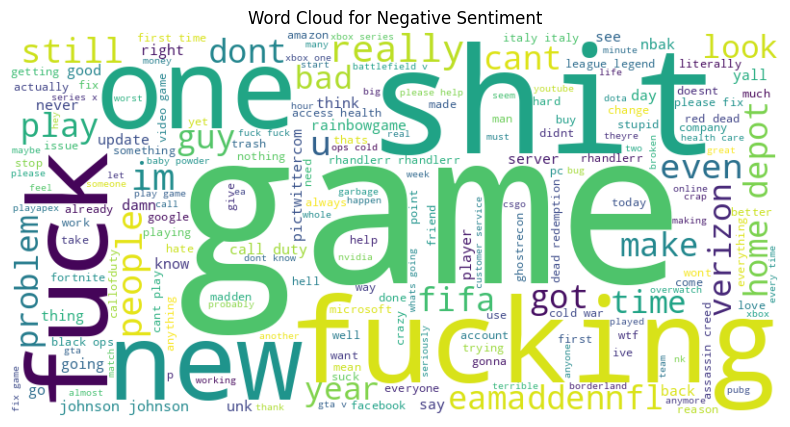

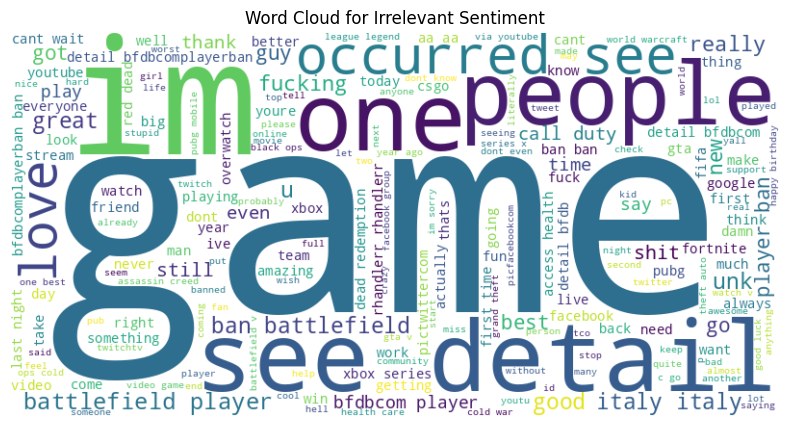

In [56]:

# Generating a word cloud for each sentiment
for sentiment in data['Sentiment'].unique():
    sentiment_text = ' '.join(data[data['Sentiment'] == sentiment]['Cleaned_Text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(sentiment_text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for {sentiment} Sentiment')
    plt.show()

